# 📊 Tutorial de Análisis de Datos Meteorológicos con Pandas y Matplotlib
Este notebook utiliza datos meteorológicos simulados de varias estaciones de la provincia de Castellón durante un año completo.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el archivo Excel
df = pd.read_csv('datos_meteorologicos_castellon.csv', sep=';', decimal=',')

# Mostrar las primeras filas
df.head()


,Fecha,Estación,Temp_Max,Temp_Min,Temp_Med,Hum_Max,Hum_Min,Hum_Med,Lluvia_Max,Lluvia_Min,Lluvia_Med,Presion_Max,Presion_Min,Presion_Med,Viento_Max,Viento_Min,Viento_Med
0,2024-01-01 00:00:00,Castellón-N,26.5,18.6,22.6,88,65,76.5,4.8,0.5,2.6,1008.5,1003.2,1005.9,18.4,8.5,13.4
1,2024-01-01 00:00:00,Benicàssim,20.7,9.0,14.9,83,67,75.0,2.2,1.8,2.0,1017.3,1014.1,1015.7,21.8,14.7,18.3
2,2024-01-01 00:00:00,Villarreal,29.4,19.5,24.4,83,62,72.5,0.0,0.0,0.0,1021.1,1016.4,1018.8,17.9,8.9,13.4
3,2024-01-01 00:00:00,Segorbe,27.7,16.9,22.3,90,44,67.0,3.3,2.5,2.9,1013.0,1009.0,1011.0,15.9,4.1,10.0
4,2024-01-01 00:00:00,Morella,30.6,20.9,25.8,93,54,73.5,0.0,0.0,0.0,1018.3,1011.8,1015.0,22.7,14.7,18.7


In [12]:
# Asegurar que la columna 'Fecha' es datetime
df['Fecha'] = pd.to_datetime(df['Fecha'])

# Agrupar por fecha, promedio entre estaciones
df_grouped = df.groupby('Fecha').mean(numeric_only=True)
df_grouped.head()


,Temp_Max,Temp_Min,Temp_Med,Hum_Max,Hum_Min,Hum_Med,Lluvia_Max,Lluvia_Min,Lluvia_Med,Presion_Max,Presion_Min,Presion_Med,Viento_Max,Viento_Min,Viento_Med
Fecha,,,,,,,,,,,,,,,
2024-01-01,26.98,16.98,22.00,87.4,58.4,72.9,2.06,0.96,1.50,1015.64,1010.90,1013.28,19.34,10.18,14.76
2024-01-02,21.86,12.14,17.00,92.2,48.6,70.4,2.64,0.60,1.62,1016.34,1011.80,1014.04,21.80,12.18,17.00
2024-01-03,24.96,14.62,19.82,89.2,52.4,70.8,2.22,1.26,1.74,1014.12,1010.20,1012.14,16.82,9.28,13.04
2024-01-04,26.30,16.66,21.48,90.0,54.4,72.2,0.86,0.26,0.58,1013.04,1006.92,1009.96,22.34,10.10,16.22
2024-01-05,24.44,12.72,18.56,87.0,59.0,73.0,3.44,1.46,2.46,1015.00,1009.50,1012.24,20.40,10.78,15.58


In [ ]:
def graficar_variable_(df_grouped, base_name, ylabel):
    plt.figure(figsize=(12, 6))
    plt.plot(df_grouped[f'{base_name}_Max'], label='Máximo', color='red', linestyle='--', linewidth=2, alpha=0.7, marker='o')
    plt.plot(df_grouped[f'{base_name}_Min'], label='Mínimo')
    plt.plot(df_grouped[f'{base_name}_Med'], label='Media')
    plt.title(f'{base_name.capitalize()} diaria en la provincia de Castellón')
    plt.xlabel('Fecha')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()


In [35]:
def graficar_variable(df_grouped, base_name, ylabel):
    plt.figure(figsize=(12, 6))
    plt.bar(df_grouped.index, df_grouped[f'{base_name}_Max'], label='Máximo', color='red', alpha=0.7)
    plt.bar(df_grouped.index, df_grouped[f'{base_name}_Min'], label='Mínimo', color='blue', alpha=0.5)
    plt.bar(df_grouped.index, df_grouped[f'{base_name}_Med'], label='Media', color='green', alpha=0.5)
    plt.title(f'{base_name.capitalize()} diaria en la provincia de Castellón (Barras)')
    plt.xlabel('Fecha')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

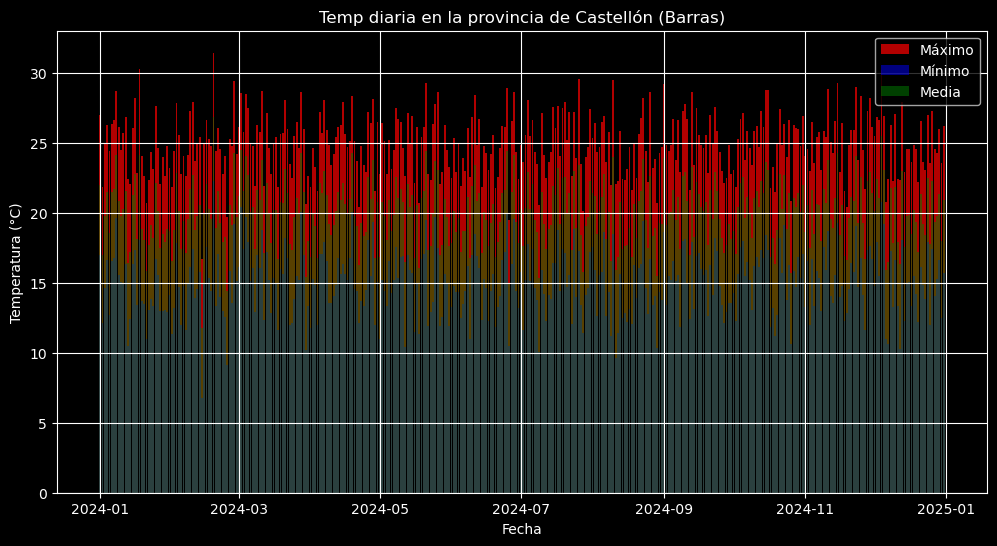

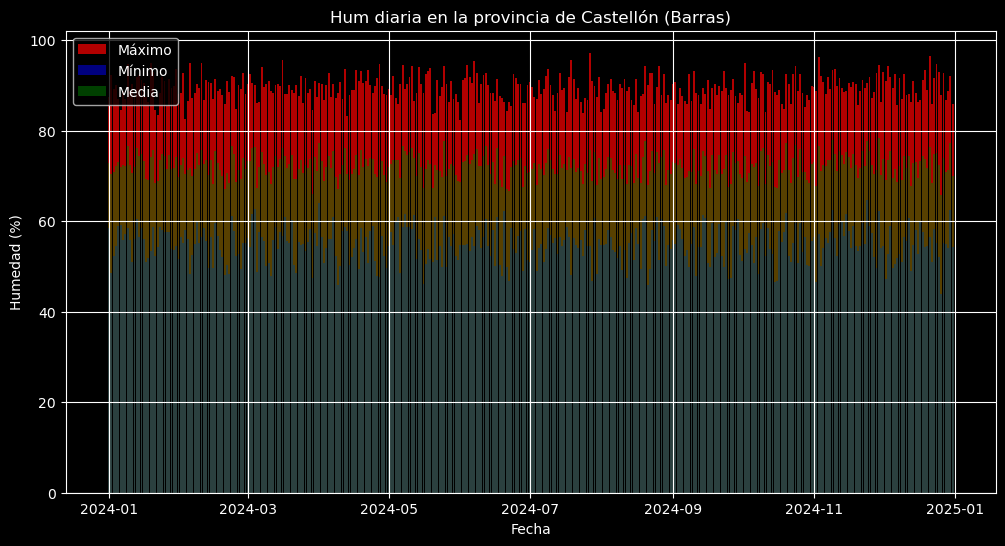

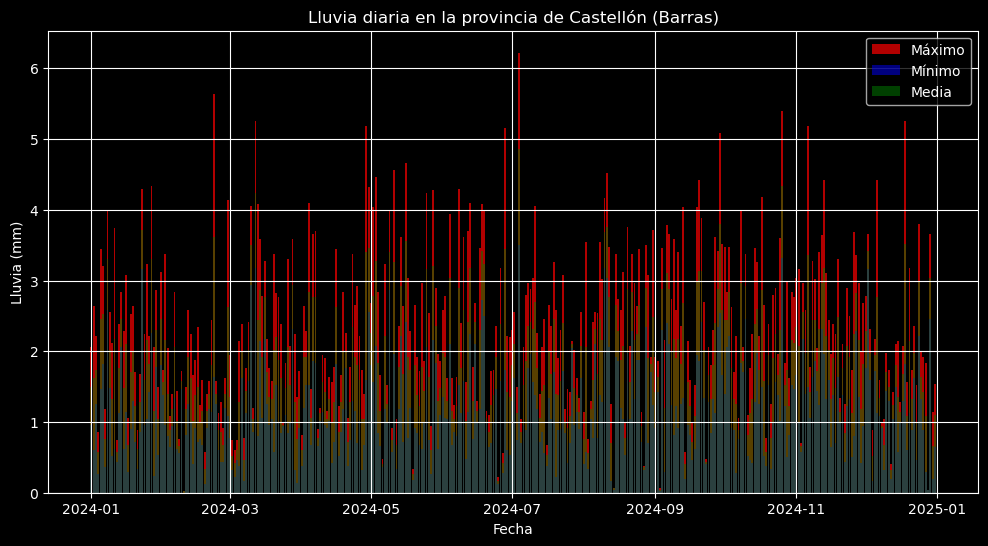

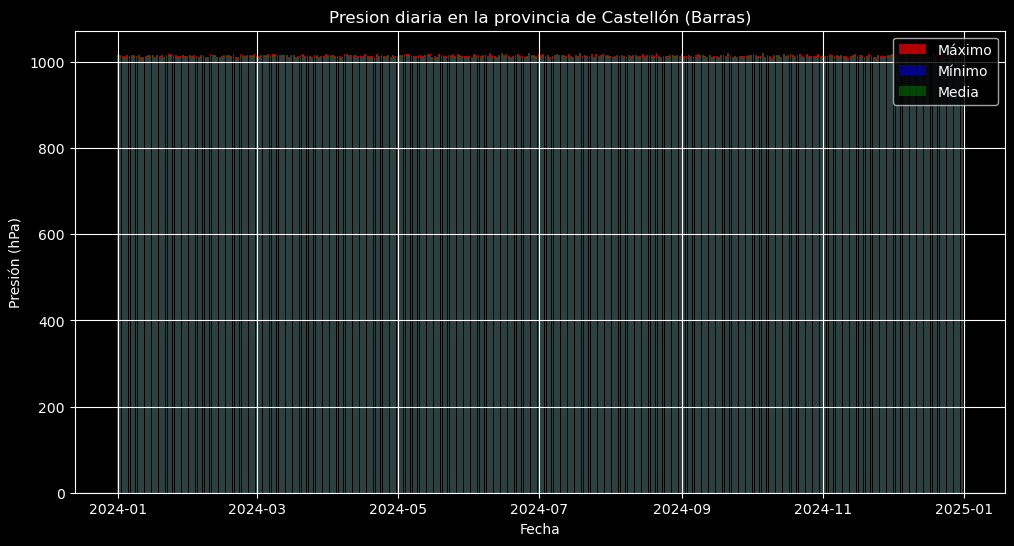

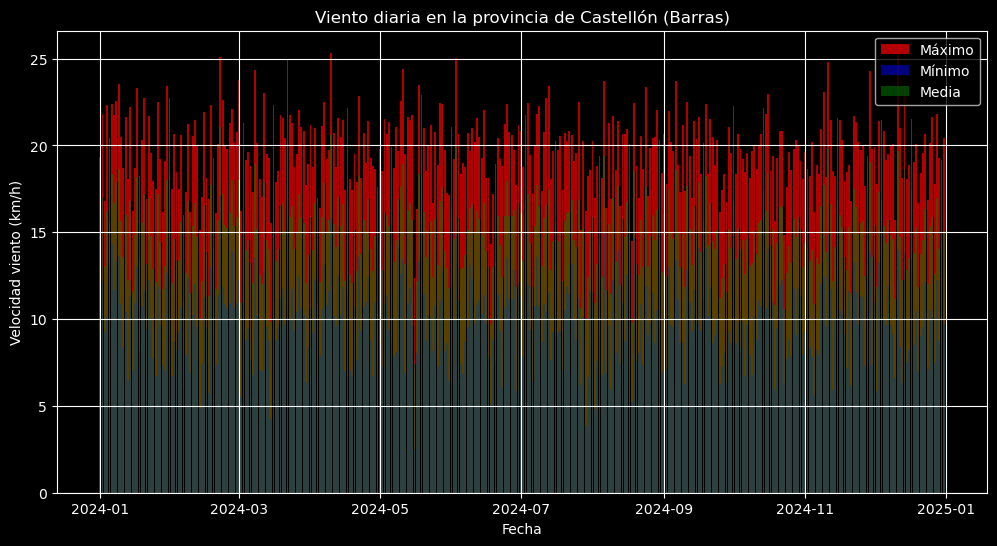

In [36]:
graficar_variable(df_grouped, 'Temp', 'Temperatura (°C)')
graficar_variable(df_grouped, 'Hum', 'Humedad (%)')
graficar_variable(df_grouped, 'Lluvia', 'Lluvia (mm)')
graficar_variable(df_grouped, 'Presion', 'Presión (hPa)')
graficar_variable(df_grouped, 'Viento', 'Velocidad viento (km/h)')


In [15]:
variables = ['Temp', 'Hum', 'Lluvia', 'Presion', 'Viento']
tipos = ['Max', 'Min', 'Med']

# DataFrame resumen
resumen = pd.DataFrame()

for var in variables:
    for tipo in tipos:
        serie = df_grouped[f'{var}_{tipo}']
        resumen.loc[f'{var}_{tipo}', 'Media'] = serie.mean()
        resumen.loc[f'{var}_{tipo}', 'Varianza'] = serie.var()
        resumen.loc[f'{var}_{tipo}', 'Desviación Std'] = serie.std()
        resumen.loc[f'{var}_{tipo}', 'Máximo'] = serie.max()
        resumen.loc[f'{var}_{tipo}', 'Mínimo'] = serie.min()

resumen


,Media,Varianza,Desviación Std,Máximo,Mínimo
Temp_Max,24.967705,4.871856,2.207228,31.46,16.74
Temp_Min,14.999399,5.529300,2.351446,22.30,6.80
Temp_Med,19.982842,4.973651,2.230168,26.88,11.78
Hum_Max,89.488525,7.897019,2.810163,97.20,82.40
Hum_Min,54.776503,15.220378,3.901330,64.60,43.80
Hum_Med,72.132514,6.434474,2.536627,78.30,65.80
Lluvia_Max,2.409180,1.262482,1.123602,6.22,0.02
Lluvia_Min,1.168852,0.450356,0.671086,3.50,0.00
Lluvia_Med,1.790000,0.714237,0.845126,4.86,0.02
Presion_Max,1014.988197,4.823023,2.196138,1021.28,1009.64


In [16]:
def graficar_estadisticas(var):
    stats = resumen.filter(like=var, axis=0)
    stats.plot(kind='bar', figsize=(12, 6))
    plt.title(f'Estadísticas anuales para {var}')
    plt.ylabel('Valor')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.show()


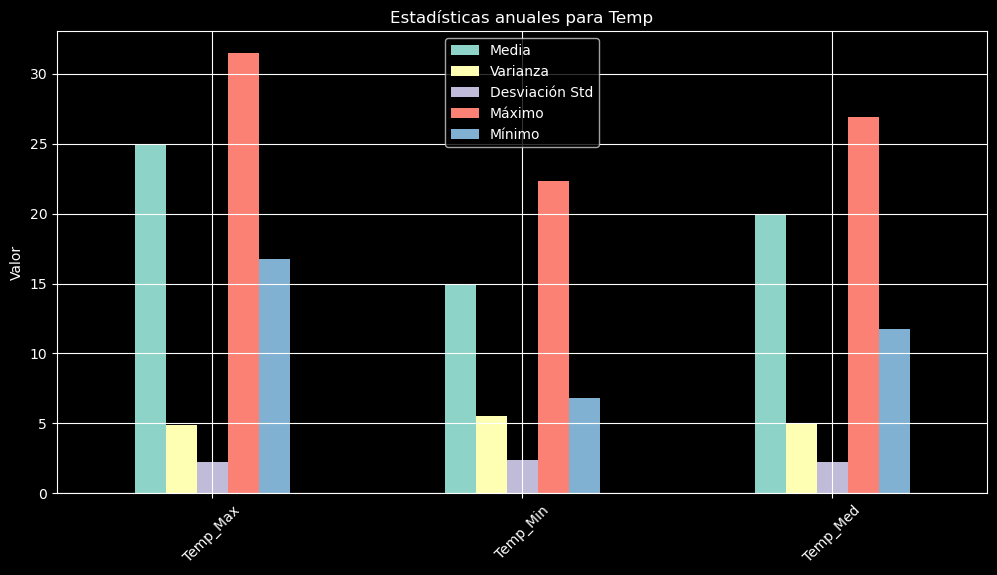

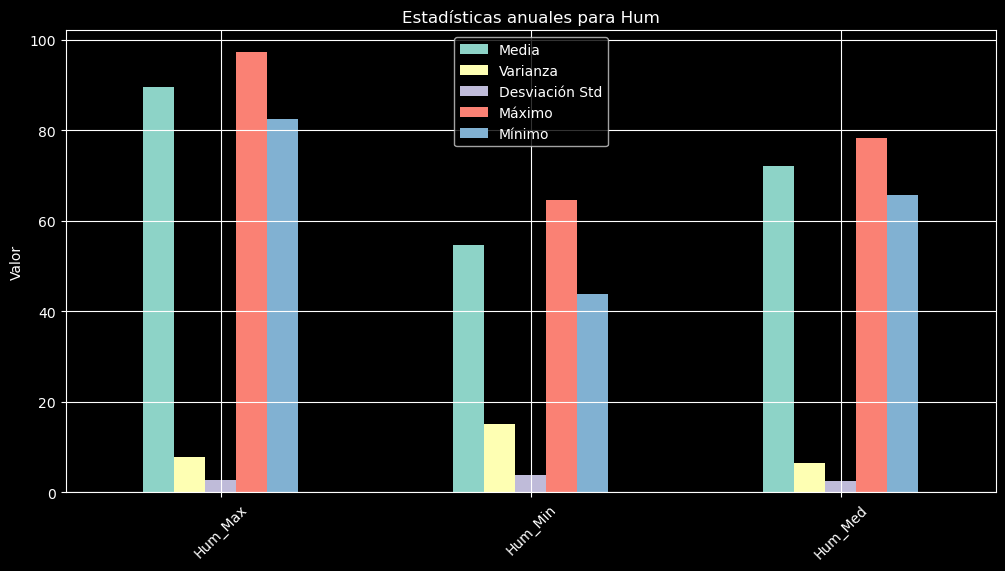

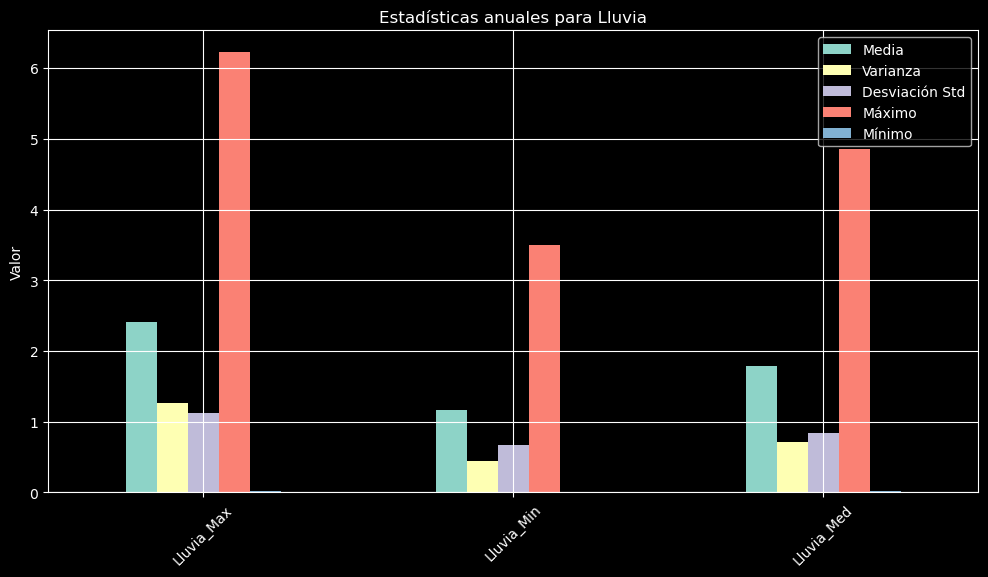

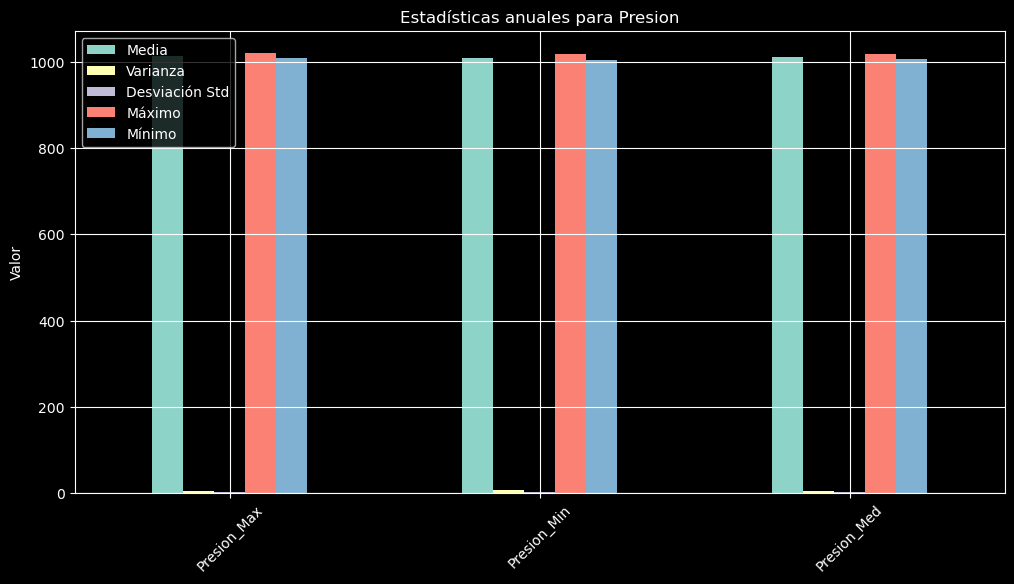

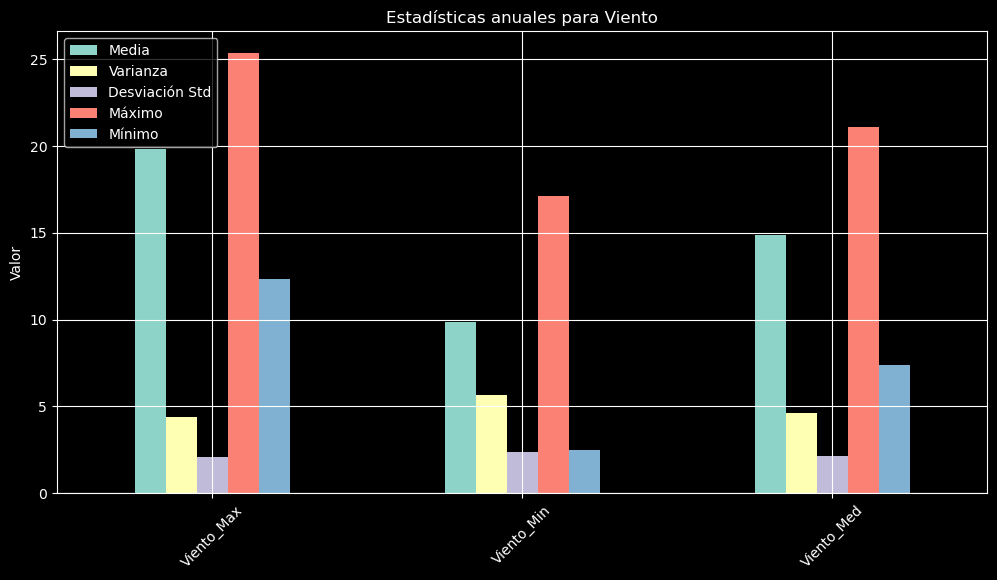

In [17]:
for var in variables:
    graficar_estadisticas(var)
